# Moving Average (MA)

## 1. Simple MA

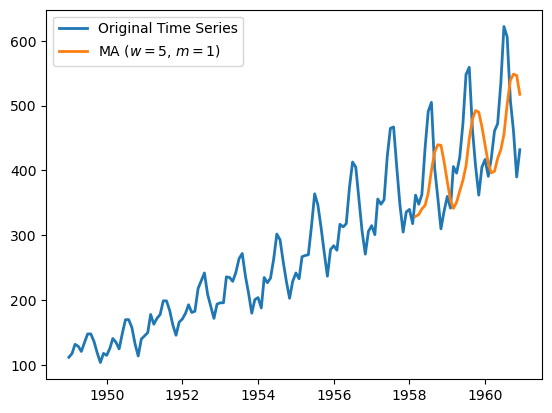

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.summarize import WindowSummarizer

y = load_airline()
# Matplotlib cannot plot PeriodIndex on the x-axis with default numpy conversion
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()
target_col = X.columns[0]

# SMA with m=1: rolling mean then shift(1) — same as WindowSummarizer "mean" with [lag, window]
w = 5
ma_tf = WindowSummarizer(
    n_jobs=1,
    lag_feature={"mean": [[1, w]]},
    target_cols=[target_col],
)
Xt_ma = ma_tf.fit_transform(X)
moving_avg = Xt_ma[f"{target_col}_mean_1_{w}"]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(moving_avg[110:], label=rf"MA ($w={w}$, $m=1$)", linewidth=2)

plt.legend()

# plt.savefig("SMA.pdf", bbox_inches='tight')

plt.show()


## 2. Exponential MA

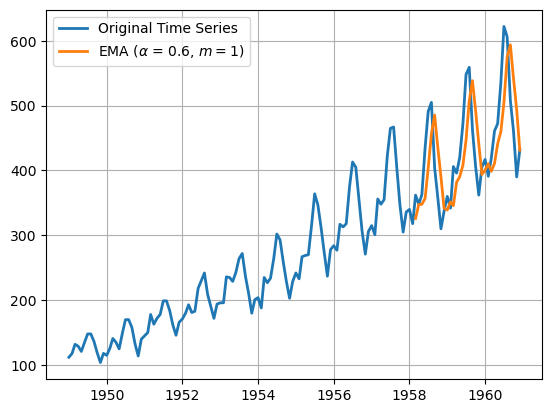

In [33]:
# Exponential Moving Average (EMWA) with alpha = 0.6 — sktime FunctionTransformer

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.func_transform import FunctionTransformer

y = load_airline()
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()

alpha = 0.6


def _ema_lagged_m1(X, alpha):
    """Same recursion as before; return level shifted by 1 (m=1)."""
    s = X.iloc[:, 0]
    emwa = s.astype(float).copy()
    emwa.iloc[0] = s.iloc[0]
    for t in range(1, len(s)):
        emwa.iloc[t] = alpha * s.iloc[t] + (1 - alpha) * emwa.iloc[t - 1]
    return emwa.shift(1).to_frame(name=X.columns[0])


ema_tf = FunctionTransformer(
    func=_ema_lagged_m1,
    kw_args={"alpha": alpha},
    check_inverse=False,
)
emwa_pred = ema_tf.fit_transform(X).iloc[:, 0]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(emwa_pred[110:], label=f"EMA ($\\alpha$ = {alpha}, $m=1$)", linewidth=2)

plt.legend()
plt.grid(True)

plt.show()


## 3. Double EMA

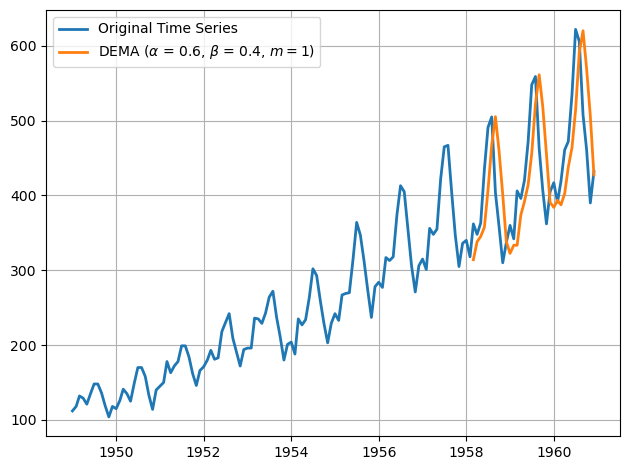

In [34]:
# Double Exponential Moving Average (DEMA) with alpha = 0.6, beta = 0.4 — sktime

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.func_transform import FunctionTransformer

y = load_airline()
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()

alpha = 0.6
beta = 0.4


def _dema_lagged_m1(X, alpha, beta):
    """Same DEMA recursion as before; plot level S shifted by 1 (m=1)."""
    s = X.iloc[:, 0]
    S = s.astype(float).copy()
    b = s.astype(float).copy()
    S.iloc[0] = s.iloc[0]
    b.iloc[0] = 0
    for t in range(1, len(s)):
        S.iloc[t] = alpha * s.iloc[t] + (1 - alpha) * (S.iloc[t - 1] + b.iloc[t - 1])
        b.iloc[t] = beta * (S.iloc[t] - S.iloc[t - 1]) + (1 - beta) * b.iloc[t - 1]
    return S.shift(1).to_frame(name=X.columns[0])


dema_tf = FunctionTransformer(
    func=_dema_lagged_m1,
    kw_args={"alpha": alpha, "beta": beta},
    check_inverse=False,
)
S_pred = dema_tf.fit_transform(X).iloc[:, 0]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(S_pred[110:], label=f"DEMA ($\\alpha$ = {alpha}, $\\beta$ = {beta}, $m=1$)", linewidth=2)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("DoubleEMA.pdf", bbox_inches="tight")

plt.show()


## 4. Holt-Winters

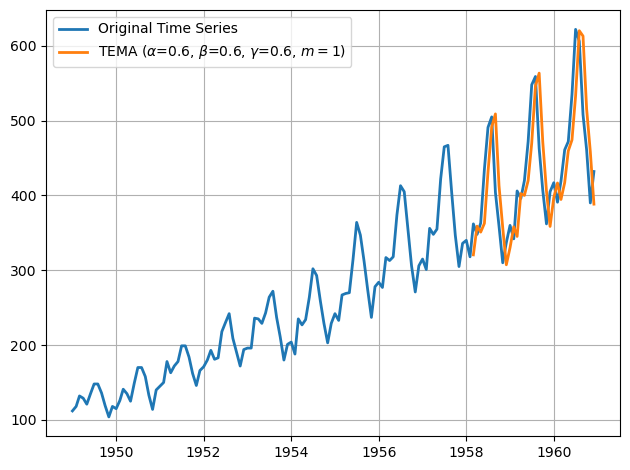

In [35]:
# Triple Exponential Moving Average (TEMA) — sktime FunctionTransformer

import matplotlib.pyplot as plt
import pandas as pd

from sktime.datasets import load_airline
from sktime.transformations.series.func_transform import FunctionTransformer

y = load_airline()
if isinstance(y.index, pd.PeriodIndex):
    y = y.copy()
    y.index = y.index.to_timestamp()
X = y.to_frame()

alpha = 0.6
beta = 0.6
gamma = 0.6


def _tema_lagged_m1(X, alpha, beta, gamma):
    """Same triple-EMA construction as before; return TEMA shifted by 1 (m=1)."""
    s = X.iloc[:, 0]
    e1 = s.astype(float).copy()
    e2 = s.astype(float).copy()
    e3 = s.astype(float).copy()
    e1.iloc[0] = s.iloc[0]
    e2.iloc[0] = s.iloc[0]
    e3.iloc[0] = s.iloc[0]
    for t in range(1, len(s)):
        e1.iloc[t] = alpha * s.iloc[t] + (1 - alpha) * e1.iloc[t - 1]
        e2.iloc[t] = beta * e1.iloc[t] + (1 - alpha) * e2.iloc[t - 1]
        e3.iloc[t] = gamma * e2.iloc[t] + (1 - alpha) * e3.iloc[t - 1]
    tema = 3 * e1 - 3 * e2 + e3
    return tema.shift(1).to_frame(name=X.columns[0])


tema_tf = FunctionTransformer(
    func=_tema_lagged_m1,
    kw_args={"alpha": alpha, "beta": beta, "gamma": gamma},
    check_inverse=False,
)
TEMA_pred = tema_tf.fit_transform(X).iloc[:, 0]

plt.figure()
plt.plot(y, label="Original Time Series", linewidth=2)
plt.plot(
    TEMA_pred[110:],
    label=f"TEMA ($\\alpha$={alpha}, $\\beta$={beta}, $\\gamma$={gamma}, $m=1$)",
    linewidth=2,
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("TripleEMA.pdf", bbox_inches="tight")

plt.show()